In [7]:
import pickle
import pandas as pd

#MCMC_Tuning is run from CMD to increase efficiency
with open('models/MCMC_XGBRegressor_Autosave_v2.sav', 'rb') as f: chains_raw = pickle.load(f)

tuned_parameters = list(chains_raw[0]['samples'][0]['params'].keys()) + ['rsme']
fixed_params = {
            'objective':'reg:squarederror',
            'booster':'gbtree',
            'eval_metric':'rmse',
            'tree_method':'hist',
            'n_estimators':200,
            'verbosity':0,
            'n_jobs':-1,
            'random_state':42
        }
chains = [pd.DataFrame(chain['samples']) for chain in chains_raw]
all_chains = pd.concat(chains, ignore_index=True)
#Drop Cuplicates from Not-Accepting
all_chains['param_str'] = all_chains['params'].apply(lambda x: str(sorted(x.items())))
all_chains = all_chains.drop_duplicates(subset='param_str', keep='first')
all_chains = all_chains.drop(columns=['param_str'])

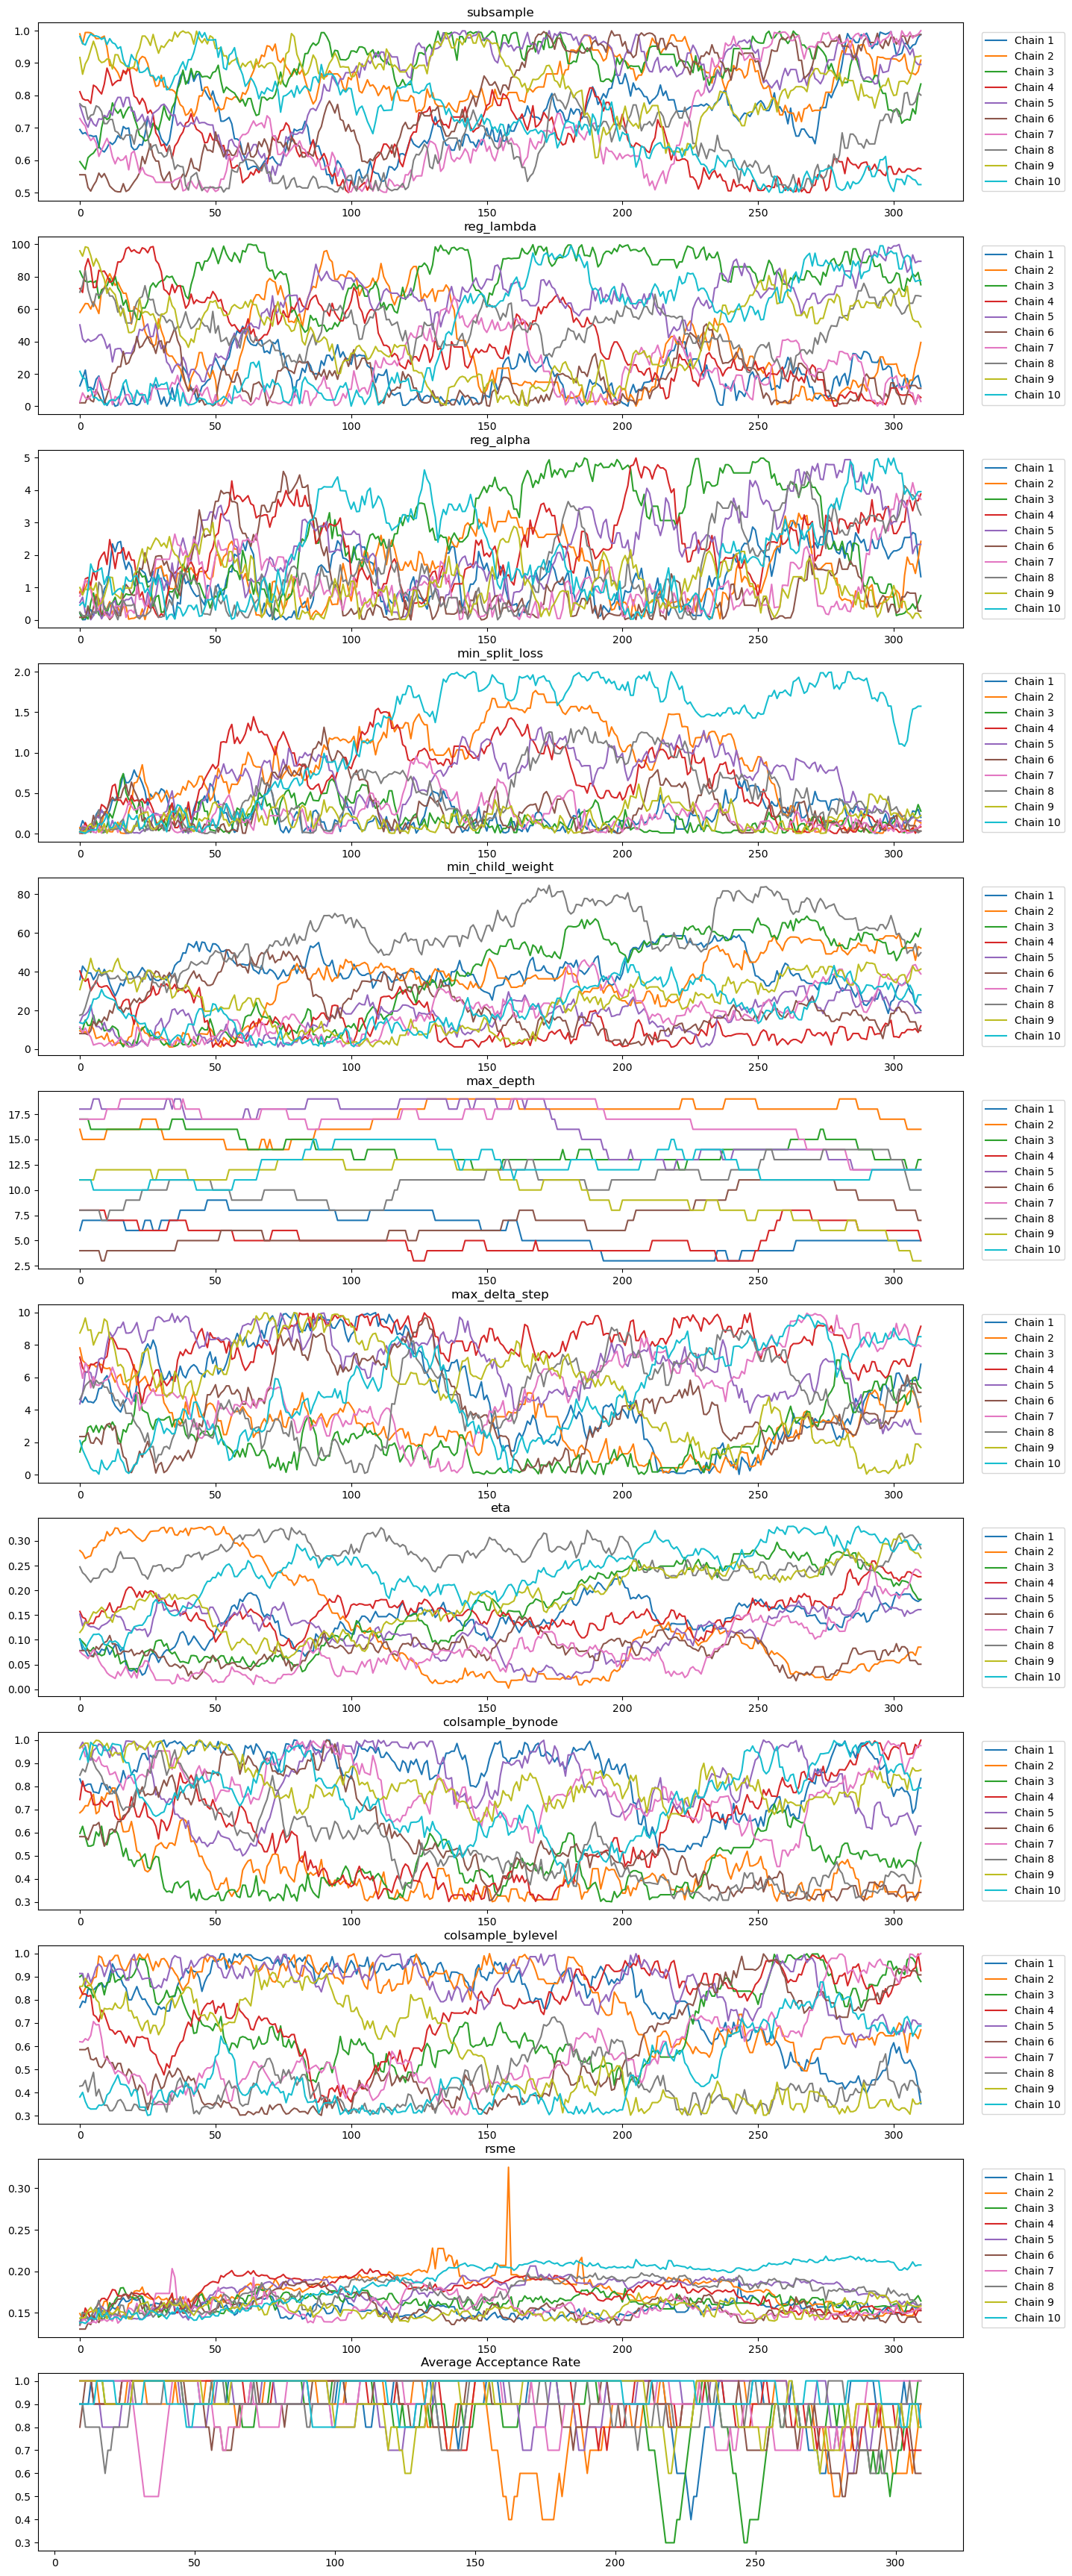

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(tuned_parameters)+1, 1, figsize=(16,len(tuned_parameters)*4))
axes = axes.flatten()

#Generate Plots for Tuned Parameters and RSME over iterations 
for parameter, ax in zip(tuned_parameters, axes):
    for i, chain in enumerate(chains):
        ax.plot(chain.index, chain[parameter], label=f'Chain {i+1}')
        ax.set_title(parameter)
        ax.legend(loc='center left',bbox_to_anchor=(1.02, 0.5),borderaxespad=0)

#Generate Plot for Acceptance Rate over time
window = 10
for i, chain in enumerate(chains_raw):
    accept_hist = chain['acceptance_history']
    avrg_accept = np.convolve(accept_hist, np.ones(window)/window, mode='valid')
    x_moving = np.arange(window-1,len(accept_hist))
    axes[-1].plot(x_moving, avrg_accept, label=f'Chain {i+1}')
    axes[-1].set_title('Average Acceptance Rate')